In [32]:

import pandas as pd
import numpy as np

In [33]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
# Create a DataFrame from the breast cancer dataset
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Save the DataFrame to a CSV file
df.to_csv('breast_cancer_dataset.csv', index=False)

print("'breast_cancer_dataset.csv' created successfully.")

'breast_cancer_dataset.csv' created successfully.


In [34]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [35]:
data = load_breast_cancer()
X = data.data
y = data.target


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

In [38]:
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

In [39]:
tree_model = DecisionTreeClassifier(criterion="gini", max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

In [40]:
print("\n=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))
print("Classification Report:\n", classification_report(y_test, y_pred_tree))



=== Decision Tree ===
Accuracy: 0.9473684210526315
Confusion Matrix:
 [[40  3]
 [ 3 68]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



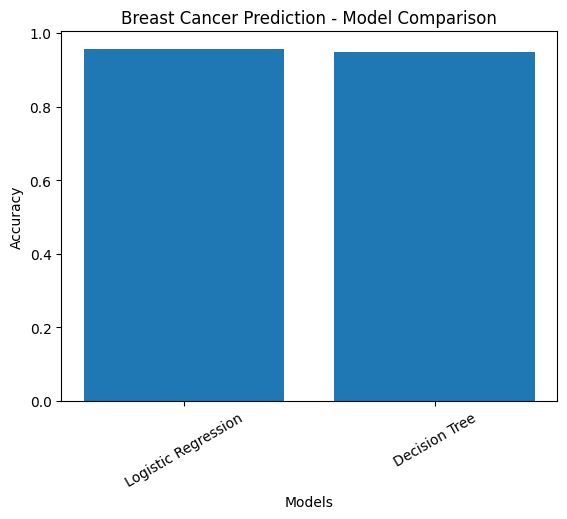

In [41]:
import matplotlib.pyplot as plt

lr_acc = accuracy_score(y_test, y_pred_log)
dt_acc = accuracy_score(y_test, y_pred_tree)

models = ['Logistic Regression', 'Decision Tree']
accuracies = [lr_acc, dt_acc]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Breast Cancer Prediction - Model Comparison")
plt.xticks(rotation=30)
plt.show()

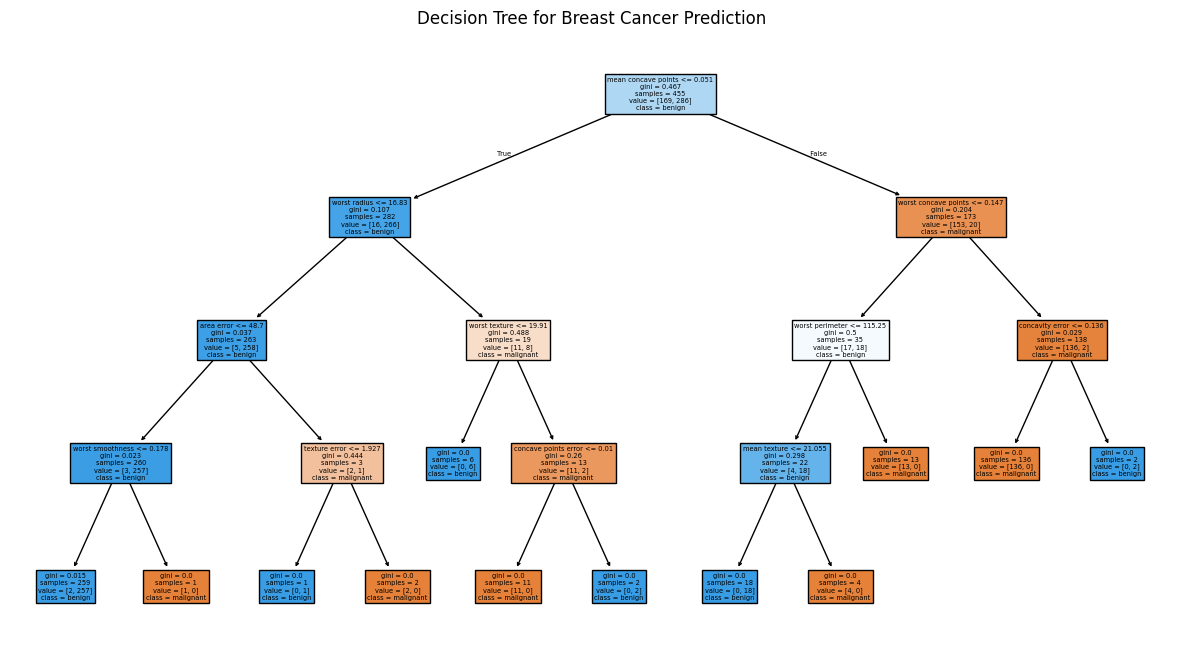

In [42]:
plt.figure(figsize=(15, 8))
plot_tree(tree_model, feature_names=data.feature_names,
          class_names=data.target_names, filled=True)
plt.title("Decision Tree for Breast Cancer Prediction")
plt.show()